
# Corrected LensPINN-Dense for DeepLense Common Task I (150×150)

This notebook is a **150×150 adaptation** of your LensPINN recreation for the three-class Common Task I setup (`no`, `sphere`, `vort`). It keeps the **physics-guided idea** from LensPINN, but fixes the parts that were most likely hurting your results:

1. **Differentiable lens inversion** using `grid_sample` instead of integer scatter indexing.
2. **Bounded Einstein-radius prediction** using a sigmoid-mapped range instead of an unbounded scalar.
3. **CLS-token based ViT head** instead of flattening all tokens directly into one scalar.
4. **DenseNet decoder** instead of EfficientNet, because your own experiments suggest DenseNet is stronger on this dataset.
5. **Native 150×150 support** instead of copying the 64×64 setup from the paper.
6. **Cleaner training loop** with early stopping, label smoothing, OneCycle scheduling, checkpointing by validation macro AUC, and optional TTA.

This is **not an exact copy** of the published LensPINN code. It is a corrected, physics-informed adaptation for the Common Task I dataset and the 150×150 images you described.



## What was most likely wrong in your current recreation

The biggest issues I corrected are:

- **Non-differentiable source reconstruction**: once you cast lens-plane coordinates to integer indices and scatter-add into a source image, gradients do not flow cleanly back into the Einstein-radius / physics encoder. That means the ViT branch is close to being a spectator instead of a learned physics module.
- **Unused `k_min` / `k_max`**: your current encoder declares these, but the predicted deflection scalar is effectively unbounded. That can make the reconstruction unstable.
- **Flatten-all-token regression head**: a CLS-token head is usually cleaner and less brittle than flattening the full token grid into one number.
- **Mismatch between the released folders and the GSoC writeup**: the task writeup asks for a 90:10 split and reports ROC/AUC for the 3-class lensing task, while your screenshot shows the provided folders are 30,000 train and 7,500 val, which is 80:20. This notebook supports both modes so you can report whichever protocol you intend to follow. fileciteturn3file0


In [1]:

# Optional installs for Kaggle / Colab.
# If timm imports fail later, the notebook automatically falls back to a built-in DenseNet-like CNN.
!pip -q install scikit-learn


In [2]:

import os
import gc
import math
import copy
import time
import random
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

try:
    import timm
    TIMM_AVAILABLE = True
    TIMM_ERROR = None
except Exception as e:
    timm = None
    TIMM_AVAILABLE = False
    TIMM_ERROR = repr(e)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)
print('TIMM_AVAILABLE =', TIMM_AVAILABLE)
if TIMM_ERROR is not None:
    print('TIMM import issue:', TIMM_ERROR)


device = cuda
TIMM_AVAILABLE = True


In [3]:

@dataclass
class CFG:
    # -------------------------- data --------------------------
    data_root: str | None = None
    class_names: tuple = ('no', 'sphere', 'vort')

    # split_mode options:
    # 1) 'provided_train_val'      -> use dataset/train and dataset/val directly
    # 2) 'strict_90_10_train_only' -> split dataset/train into 90:10
    # 3) 'strict_90_10_all'        -> merge train+val then re-split 90:10
    split_mode: str = 'provided_train_val'

    # -------------------------- image / physics --------------------------
    img_size: int = 150
    patch_size: int = 25   # 150 % 25 == 0  -> 36 patches
    einstein_min: float = 0.05
    einstein_max: float = 0.60

    # -------------------------- model --------------------------
    backbone_name: str = 'densenet121'   # try 'densenet169' second
    use_pretrained_backbone: bool = True
    embed_dim: int = 256
    vit_depth: int = 2
    num_heads: int = 8
    vit_mlp_ratio: float = 2.0
    dropout: float = 0.20

    # -------------------------- train --------------------------
    batch_size: int = 8
    accum_steps: int = 2           # effective batch = 16
    num_workers: int = 2
    epochs: int = 25
    patience: int = 6
    max_lr: float = 2e-4
    weight_decay: float = 1e-4
    label_smoothing: float = 0.05
    use_amp: bool = True
    grad_clip: float = 1.0

    # -------------------------- augmentation --------------------------
    train_hflip: float = 0.5
    train_vflip: float = 0.5
    train_rot90: bool = True
    gaussian_noise_std: float = 0.01

    # -------------------------- misc --------------------------
    save_dir: str = './outputs_lenspinn_dense'
    run_smoke_test_only: bool = False

cfg = CFG()
os.makedirs(cfg.save_dir, exist_ok=True)
cfg


CFG(data_root=None, class_names=('no', 'sphere', 'vort'), split_mode='provided_train_val', img_size=150, patch_size=25, einstein_min=0.05, einstein_max=0.6, backbone_name='densenet121', use_pretrained_backbone=True, embed_dim=256, vit_depth=2, num_heads=8, vit_mlp_ratio=2.0, dropout=0.2, batch_size=8, accum_steps=2, num_workers=2, epochs=25, patience=6, max_lr=0.0002, weight_decay=0.0001, label_smoothing=0.05, use_amp=True, grad_clip=1.0, train_hflip=0.5, train_vflip=0.5, train_rot90=True, gaussian_noise_std=0.01, save_dir='./outputs_lenspinn_dense', run_smoke_test_only=False)


## Recommended starting point

These are the defaults I would start with for your 150×150 DenseNet-based LensPINN recreation:

- `backbone_name='densenet121'`
- `patch_size=25`
- `embed_dim=256`
- `vit_depth=2`
- `num_heads=8`
- `dropout=0.20`
- `epochs=25`
- `patience=6`
- `max_lr=2e-4`
- `weight_decay=1e-4`
- `label_smoothing=0.05`
- `batch_size=8`, `accum_steps=2`

Then try **one** extra run with `backbone_name='densenet169'` and the same settings. That is the first comparison I would trust.


In [4]:

def resolve_data_root(explicit_root=None):
    candidates = []
    if explicit_root is not None:
        candidates.append(Path(explicit_root))
    candidates.extend([
        Path('/kaggle/input/common-task-dataset/dataset'),
        Path('/kaggle/input/datasets/arushhh/common-task-dataset/dataset'),
        Path('/kaggle/input/datasets/ashaeyx/common-task-dataset/dataset'),
        Path('./dataset'),
    ])
    for root in candidates:
        if (root / 'train').exists() and (root / 'val').exists():
            return root
    raise FileNotFoundError('Could not find dataset root. Set cfg.data_root manually.')


def list_image_files(folder):
    exts = {'.npy', '.npz', '.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff', '.webp'}
    return sorted([p for p in Path(folder).iterdir() if p.suffix.lower() in exts])


def load_one_image(path, img_size):
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix == '.npy':
        arr = np.load(path, allow_pickle=True)
    elif suffix == '.npz':
        npz = np.load(path, allow_pickle=True)
        key = list(npz.keys())[0]
        arr = npz[key]
    else:
        from PIL import Image
        arr = np.array(Image.open(path).convert('F'))

    arr = np.asarray(arr, dtype=np.float32)
    arr = np.squeeze(arr)
    if arr.ndim == 3:
        if arr.shape[0] == 1:
            arr = arr[0]
        elif arr.shape[-1] == 1:
            arr = arr[..., 0]
        else:
            arr = arr.squeeze()

    if arr.ndim != 2:
        raise ValueError(f'Expected 2D image after squeeze, got {arr.shape} from {path}')

    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    # Renormalize only when the range is obviously not already [0, 1].
    if arr.min() < -0.05 or arr.max() > 1.05:
        mn, mx = float(arr.min()), float(arr.max())
        if mx > mn:
            arr = (arr - mn) / (mx - mn)
        else:
            arr = np.zeros_like(arr, dtype=np.float32)

    ten = torch.tensor(arr, dtype=torch.float32)[None, None]
    if arr.shape != (img_size, img_size):
        ten = F.interpolate(ten, size=(img_size, img_size), mode='bilinear', align_corners=False)

    arr = ten[0, 0].cpu().numpy().astype(np.float32)
    arr = np.clip(arr, 1e-6, 1.0)
    return arr


def gather_paths_labels(split_root, class_names):
    paths, labels = [], []
    split_root = Path(split_root)
    for class_idx, class_name in enumerate(class_names):
        class_dir = split_root / class_name
        files = list_image_files(class_dir)
        paths.extend([str(x) for x in files])
        labels.extend([class_idx] * len(files))
    return paths, np.asarray(labels, dtype=np.int64)


def build_splits(cfg):
    root = resolve_data_root(cfg.data_root)
    train_root = root / 'train'
    val_root = root / 'val'

    train_paths, train_labels = gather_paths_labels(train_root, cfg.class_names)
    val_paths, val_labels = gather_paths_labels(val_root, cfg.class_names)

    if cfg.split_mode == 'provided_train_val':
        pass
    elif cfg.split_mode == 'strict_90_10_train_only':
        idx = np.arange(len(train_labels))
        tr_idx, va_idx = train_test_split(
            idx, test_size=0.10, random_state=SEED, shuffle=True, stratify=train_labels
        )
        train_paths = [train_paths[i] for i in tr_idx]
        train_labels = train_labels[tr_idx]
        val_paths = [train_paths[i] for i in range(len(train_paths))]  # placeholder to keep structure simple
        val_labels = train_labels.copy()
        # re-create split cleanly from the original lists
        orig_train_paths, orig_train_labels = gather_paths_labels(train_root, cfg.class_names)
        train_paths = [orig_train_paths[i] for i in tr_idx]
        train_labels = orig_train_labels[tr_idx]
        val_paths = [orig_train_paths[i] for i in va_idx]
        val_labels = orig_train_labels[va_idx]
    elif cfg.split_mode == 'strict_90_10_all':
        all_paths = train_paths + val_paths
        all_labels = np.concatenate([train_labels, val_labels])
        idx = np.arange(len(all_labels))
        tr_idx, va_idx = train_test_split(
            idx, test_size=0.10, random_state=SEED, shuffle=True, stratify=all_labels
        )
        train_paths = [all_paths[i] for i in tr_idx]
        train_labels = all_labels[tr_idx]
        val_paths = [all_paths[i] for i in va_idx]
        val_labels = all_labels[va_idx]
    else:
        raise ValueError(f'Unknown split_mode: {cfg.split_mode}')

    return root, train_paths, np.asarray(train_labels), val_paths, np.asarray(val_labels)


def summarize_split(paths, labels, class_names, name='split'):
    print(f'{name} size =', len(paths))
    print(pd.Series([class_names[i] for i in labels]).value_counts().sort_index())

DATA_ROOT, train_paths, train_labels, val_paths, val_labels = build_splits(cfg)
print('Using DATA_ROOT =', DATA_ROOT)
print('split_mode =', cfg.split_mode)
summarize_split(train_paths, train_labels, cfg.class_names, name='train')
summarize_split(val_paths, val_labels, cfg.class_names, name='val')
print('first image shape =', load_one_image(train_paths[0], cfg.img_size).shape)


Using DATA_ROOT = /kaggle/input/datasets/arushhh/common-task-dataset/dataset
split_mode = provided_train_val
train size = 30000
no        10000
sphere    10000
vort      10000
Name: count, dtype: int64
val size = 7500
no        2500
sphere    2500
vort      2500
Name: count, dtype: int64
first image shape = (150, 150)


In [5]:

def physics_preprocess_torch(image2d: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    # Implements |tanh( ∂x ∂y [ log(Imax / I)^2 ] )|
    image2d = image2d.clamp_min(eps)
    imax = torch.amax(image2d)
    x = torch.log((imax + eps) / image2d).pow(2)
    gx = torch.gradient(x, dim=(0,))[0]
    gxy = torch.gradient(gx, dim=(1,))[0]
    return torch.tanh(gxy).abs()


def apply_train_aug(image2d: torch.Tensor, cfg: CFG) -> torch.Tensor:
    if random.random() < cfg.train_hflip:
        image2d = torch.flip(image2d, dims=(-1,))
    if random.random() < cfg.train_vflip:
        image2d = torch.flip(image2d, dims=(-2,))
    if cfg.train_rot90:
        k = random.randint(0, 3)
        image2d = torch.rot90(image2d, k=k, dims=(-2, -1))
    if cfg.gaussian_noise_std > 0:
        if random.random() < 0.25:
            image2d = image2d + cfg.gaussian_noise_std * torch.randn_like(image2d)
            image2d = image2d.clamp(1e-6, 1.0)
    return image2d


class LensDataset(Dataset):
    def __init__(self, paths, labels, cfg: CFG, train: bool = False):
        self.paths = list(paths)
        self.labels = np.asarray(labels, dtype=np.int64)
        self.cfg = cfg
        self.train = train

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = load_one_image(self.paths[idx], self.cfg.img_size)
        img = torch.tensor(img, dtype=torch.float32)

        if self.train:
            img = apply_train_aug(img, self.cfg)

        pre = physics_preprocess_torch(img)
        target = torch.tensor(int(self.labels[idx]), dtype=torch.long)

        # return CHW tensors
        return img.unsqueeze(0), pre.unsqueeze(0), target

train_dataset = LensDataset(train_paths, train_labels, cfg, train=True)
val_dataset = LensDataset(val_paths, val_labels, cfg, train=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=True,
    drop_last=False,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
    drop_last=False,
)

x0, p0, y0 = train_dataset[0]
print('sample image:', x0.shape, x0.min().item(), x0.max().item())
print('sample pre  :', p0.shape, p0.min().item(), p0.max().item())
print('sample label:', y0.item())


sample image: torch.Size([1, 150, 150]) 9.999999974752427e-07 0.9915806651115417
sample pre  : torch.Size([1, 150, 150]) 0.0 1.0
sample label: 0


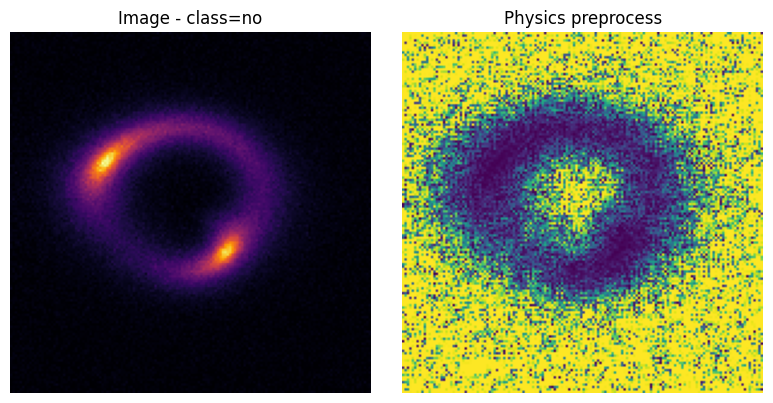

In [6]:

# Visual sanity check
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(x0[0].numpy(), cmap='inferno')
axes[0].set_title(f'Image - class={cfg.class_names[y0.item()]}')
axes[0].axis('off')
axes[1].imshow(p0[0].numpy(), cmap='viridis')
axes[1].set_title('Physics preprocess')
axes[1].axis('off')
plt.tight_layout()
plt.show()



## Model

The physics path here does **three** important things differently from your current notebook:

- predicts a **bounded** Einstein radius,
- reconstructs a source-like image with a **differentiable warp**,
- uses a **CLS-token regression head** for the ViT block.

The decoder then uses:

- **shared DenseNet features** for the raw image and reconstructed source,
- **another DenseNet branch** for the physics preprocessing image,
- `|f(image) - f(source)|` as the residual-style physics feature,
- the predicted Einstein-radius embedding as an extra feature.


In [7]:

def zero_pad_translate(x: torch.Tensor, dx: int, dy: int) -> torch.Tensor:
    # x: [B, C, H, W]
    out = torch.zeros_like(x)
    _, _, H, W = x.shape

    src_x0 = max(-dx, 0)
    src_x1 = W - max(dx, 0)
    dst_x0 = max(dx, 0)
    dst_x1 = W - max(-dx, 0)

    src_y0 = max(-dy, 0)
    src_y1 = H - max(dy, 0)
    dst_y0 = max(dy, 0)
    dst_y1 = H - max(-dy, 0)

    if src_x1 > src_x0 and src_y1 > src_y0:
        out[:, :, dst_y0:dst_y1, dst_x0:dst_x1] = x[:, :, src_y0:src_y1, src_x0:src_x1]
    return out


class ShiftPatchTokenizer(nn.Module):
    def __init__(self, image_size=150, patch_size=25, in_chans=1, embed_dim=256, mode='diagonal'):
        super().__init__()
        assert image_size % patch_size == 0, 'image_size must be divisible by patch_size'
        self.image_size = image_size
        self.patch_size = patch_size
        self.in_chans = in_chans
        self.embed_dim = embed_dim
        self.mode = mode
        self.num_patches = (image_size // patch_size) ** 2

        shift = patch_size // 2
        if mode == 'diagonal':
            self.shift_pairs = [(0, 0), (-shift, -shift), (shift, -shift), (-shift, shift), (shift, shift)]
        elif mode == 'rectangular':
            self.shift_pairs = [(0, 0), (0, -shift), (0, shift), (-shift, 0), (shift, 0)]
        else:
            raise ValueError('mode must be diagonal or rectangular')

        self.proj = nn.Conv2d(in_chans * len(self.shift_pairs), embed_dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        shifted = [zero_pad_translate(x, dx, dy) for dx, dy in self.shift_pairs]
        x = torch.cat(shifted, dim=1)
        x = self.proj(x).flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1)
        return x + self.pos_embed


class MaskedAttentionBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, num_tokens, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim),
            nn.Dropout(dropout),
        )
        # True entries are masked out in PyTorch attention masks.
        self.register_buffer('attn_mask', torch.eye(num_tokens, dtype=torch.bool), persistent=False)

    def forward(self, x):
        y = self.norm1(x)
        attn_out, _ = self.attn(y, y, y, attn_mask=self.attn_mask)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class DifferentiableLensInversion(nn.Module):
    def __init__(self, image_size=150, theta_e_min=0.05, theta_e_max=0.60, eps=1e-4):
        super().__init__()
        self.theta_e_min = theta_e_min
        self.theta_e_max = theta_e_max
        self.eps = eps
        yy, xx = torch.meshgrid(
            torch.linspace(-1.0, 1.0, image_size),
            torch.linspace(-1.0, 1.0, image_size),
            indexing='ij'
        )
        self.register_buffer('xx', xx, persistent=False)
        self.register_buffer('yy', yy, persistent=False)

    def forward(self, image, theta_raw):
        # theta_raw: [B, 1]
        theta_e = self.theta_e_min + (self.theta_e_max - self.theta_e_min) * torch.sigmoid(theta_raw).view(-1, 1, 1)
        r = torch.sqrt(self.xx ** 2 + self.yy ** 2 + self.eps)
        beta_x = self.xx.unsqueeze(0) - theta_e * self.xx.unsqueeze(0) / r.unsqueeze(0)
        beta_y = self.yy.unsqueeze(0) - theta_e * self.yy.unsqueeze(0) / r.unsqueeze(0)
        grid = torch.stack([beta_x, beta_y], dim=-1).clamp(-1, 1)
        source = F.grid_sample(image, grid, mode='bilinear', padding_mode='zeros', align_corners=True)
        return theta_e.squeeze(-1).squeeze(-1), source


class DenseLayer(nn.Module):
    def __init__(self, in_ch, growth_rate, bn_size=4, drop_rate=0.0):
        super().__init__()
        inter = bn_size * growth_rate
        self.net = nn.Sequential(
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, inter, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter),
            nn.ReLU(inplace=True),
            nn.Conv2d(inter, growth_rate, kernel_size=3, padding=1, bias=False),
        )
        self.drop_rate = drop_rate

    def forward(self, x):
        new = self.net(x)
        if self.drop_rate > 0:
            new = F.dropout(new, p=self.drop_rate, training=self.training)
        return torch.cat([x, new], dim=1)


class DenseBlock(nn.Module):
    def __init__(self, num_layers, in_ch, growth_rate, drop_rate=0.0):
        super().__init__()
        layers = []
        ch = in_ch
        for _ in range(num_layers):
            layers.append(DenseLayer(ch, growth_rate, drop_rate=drop_rate))
            ch += growth_rate
        self.block = nn.Sequential(*layers)
        self.out_ch = ch

    def forward(self, x):
        return self.block(x)


class Transition(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.AvgPool2d(kernel_size=2, stride=2),
        )

    def forward(self, x):
        return self.net(x)


class FallbackDenseNetFeatures(nn.Module):
    """
    Small built-in DenseNet-like backbone used only when timm DenseNet cannot be loaded.
    This keeps the notebook runnable even in restricted environments.
    """
    def __init__(self, in_chans=1, growth_rate=16, block_layers=(4, 6, 8), drop_rate=0.0):
        super().__init__()
        channels = 32
        self.stem = nn.Sequential(
            nn.Conv2d(in_chans, channels, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        blocks = []
        for i, n in enumerate(block_layers):
            db = DenseBlock(n, channels, growth_rate, drop_rate=drop_rate)
            blocks.append(db)
            channels = db.out_ch
            if i != len(block_layers) - 1:
                out_ch = channels // 2
                blocks.append(Transition(channels, out_ch))
                channels = out_ch

        self.features = nn.Sequential(*blocks)
        self.final_norm = nn.BatchNorm2d(channels)
        self.num_features = channels

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = F.relu(self.final_norm(x), inplace=False)
        x = F.adaptive_avg_pool2d(x, (1, 1)).flatten(1)
        return x


class TimmDenseNetFeatures(nn.Module):
    def __init__(self, model_name='densenet121', pretrained=True):
        super().__init__()
        self.model = timm.create_model(
            model_name,
            pretrained=pretrained,
            in_chans=1,
            num_classes=0,
            global_pool='avg'
        )
        self.num_features = self.model.num_features

    def forward(self, x):
        return self.model(x)


def build_dense_features(model_name='densenet121', pretrained=True, dropout=0.2):
    if TIMM_AVAILABLE:
        try:
            print(f'Using timm backbone: {model_name} | pretrained={pretrained}')
            return TimmDenseNetFeatures(model_name=model_name, pretrained=pretrained)
        except Exception as e:
            print('timm DenseNet creation failed, falling back to built-in DenseNet-like CNN:', repr(e))
    else:
        print('timm unavailable, using built-in DenseNet-like CNN fallback')

    return FallbackDenseNetFeatures(in_chans=1, growth_rate=16, block_layers=(4, 6, 8), drop_rate=dropout * 0.25)


class PhysicsEncoder(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.tokenizer = ShiftPatchTokenizer(
            image_size=cfg.img_size,
            patch_size=cfg.patch_size,
            in_chans=1,
            embed_dim=cfg.embed_dim,
            mode='diagonal'
        )
        num_tokens = self.tokenizer.num_patches + 1
        self.blocks = nn.ModuleList([
            MaskedAttentionBlock(
                embed_dim=cfg.embed_dim,
                num_heads=cfg.num_heads,
                num_tokens=num_tokens,
                mlp_ratio=cfg.vit_mlp_ratio,
                dropout=cfg.dropout,
            )
            for _ in range(cfg.vit_depth)
        ])
        self.norm = nn.LayerNorm(cfg.embed_dim)
        self.theta_head = nn.Sequential(
            nn.Linear(cfg.embed_dim, cfg.embed_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.embed_dim, 1),
        )
        self.inverter = DifferentiableLensInversion(
            image_size=cfg.img_size,
            theta_e_min=cfg.einstein_min,
            theta_e_max=cfg.einstein_max,
        )

    def forward(self, image):
        x = self.tokenizer(image)
        for blk in self.blocks:
            x = blk(x)
        cls = self.norm(x[:, 0])
        theta_raw = self.theta_head(cls)
        theta_e, source = self.inverter(image, theta_raw)
        return theta_e.unsqueeze(1), source


class DenseLensPINN(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.cfg = cfg
        self.physics = PhysicsEncoder(cfg)
        self.cnn_shared = build_dense_features(cfg.backbone_name, cfg.use_pretrained_backbone, cfg.dropout)
        self.cnn_pre = build_dense_features(cfg.backbone_name, cfg.use_pretrained_backbone, cfg.dropout)

        feat_dim = self.cnn_shared.num_features
        self.norm_img = nn.LayerNorm(feat_dim)
        self.norm_diff = nn.LayerNorm(feat_dim)
        self.norm_pre = nn.LayerNorm(feat_dim)

        self.theta_mlp = nn.Sequential(
            nn.Linear(1, 32),
            nn.GELU(),
            nn.Linear(32, 64),
        )

        self.head = nn.Sequential(
            nn.Linear(feat_dim * 3 + 64, 512),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(cfg.dropout * 0.5),
            nn.Linear(128, len(cfg.class_names)),
        )

    def forward(self, image, pre):
        theta_e, source = self.physics(image)

        img_raw = self.cnn_shared(image)
        src_raw = self.cnn_shared(source)
        pre_raw = self.cnn_pre(pre)

        f_img = self.norm_img(img_raw)
        f_diff = self.norm_diff(torch.abs(img_raw - src_raw))
        f_pre = self.norm_pre(pre_raw)
        theta_f = self.theta_mlp(theta_e)

        fused = torch.cat([f_img, f_diff, f_pre, theta_f], dim=1)
        logits = self.head(fused)
        return theta_e, source, logits


In [8]:

# Smoke test before real training
model = DenseLensPINN(cfg).to(device)
model.eval()
with torch.no_grad():
    xb, pb, yb = next(iter(val_loader))
    xb = xb[:2].to(device)
    pb = pb[:2].to(device)
    theta_e, source, logits = model(xb, pb)
print('theta_e:', theta_e.shape)
print('source :', source.shape)
print('logits :', logits.shape)
print('params :', f"{sum(p.numel() for p in model.parameters())/1e6:.2f}M")


Using timm backbone: densenet121 | pretrained=True


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

Using timm backbone: densenet121 | pretrained=True
theta_e: torch.Size([2, 1])
source : torch.Size([2, 1, 150, 150])
logits : torch.Size([2, 3])
params : 17.51M



## Training helpers

A few choices here are deliberate:

- **CrossEntropyLoss with label smoothing** on raw logits.
- **OneCycleLR** instead of a flat LR.
- **Early stopping on validation macro AUC**.
- **Gradient accumulation** because 150×150 + DenseNet + ViT can be memory-heavy.


In [9]:

def compute_multiclass_metrics(y_true, y_prob, class_names):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = np.argmax(y_prob, axis=1)
    y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))

    metrics = {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'micro_f1': float(f1_score(y_true, y_pred, average='micro')),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro')),
        'macro_auc': float(roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovr')),
        'micro_auc': float(roc_auc_score(y_true_bin, y_prob, average='micro', multi_class='ovr')),
    }
    per_class_auc = {}
    for i, cname in enumerate(class_names):
        per_class_auc[cname] = float(roc_auc_score(y_true_bin[:, i], y_prob[:, i]))
    return metrics, per_class_auc, y_pred


def plot_history(history, model_name='model'):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(history['train_loss'], label='train')
    axes[0].plot(history['val_loss'], label='val')
    axes[0].set_title(f'{model_name} loss')
    axes[0].legend()

    axes[1].plot(history['val_macro_f1'], label='val macro F1')
    axes[1].set_title(f'{model_name} macro F1')
    axes[1].legend()

    axes[2].plot(history['val_macro_auc'], label='val macro AUC')
    axes[2].set_title(f'{model_name} macro AUC')
    axes[2].legend()
    plt.tight_layout()
    plt.show()


def maybe_tta_predict(model, image, pre):
    # light test-time augmentation: average over identity and horizontal flip
    theta1, src1, logits1 = model(image, pre)
    image_flip = torch.flip(image, dims=(-1,))
    pre_flip = torch.flip(pre, dims=(-1,))
    theta2, src2, logits2 = model(image_flip, pre_flip)
    logits = 0.5 * (logits1 + logits2)
    return theta1, src1, logits


def train_model(model, train_loader, val_loader, cfg: CFG, device):
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.max_lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=cfg.max_lr,
        epochs=cfg.epochs,
        steps_per_epoch=max(1, len(train_loader)),
        pct_start=0.10,
        div_factor=10.0,
        final_div_factor=100.0,
        anneal_strategy='cos'
    )
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda' and cfg.use_amp))

    model_name = f"DenseLensPINN_{cfg.backbone_name}_{cfg.img_size}"
    ckpt_path = os.path.join(cfg.save_dir, model_name + '_best.pth')

    history = defaultdict(list)
    best_auc = -1.0
    best_state = None
    epochs_without_improve = 0

    for epoch in range(cfg.epochs):
        # ------------------ train ------------------
        model.train()
        optimizer.zero_grad(set_to_none=True)
        train_losses = []

        pbar = train_loader
        if not cfg.run_smoke_test_only:
            from tqdm.auto import tqdm
            pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{cfg.epochs} [train]')

        for step, (image, pre, target) in enumerate(pbar):
            image = image.to(device, non_blocking=True)
            pre = pre.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda' and cfg.use_amp)):
                _, _, logits = model(image, pre)
                loss = criterion(logits, target) / cfg.accum_steps

            scaler.scale(loss).backward()

            if ((step + 1) % cfg.accum_steps == 0) or ((step + 1) == len(train_loader)):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

            scheduler.step()
            train_losses.append(loss.item() * cfg.accum_steps)

        # ------------------ val ------------------
        model.eval()
        val_losses = []
        y_true, y_prob = [], []

        with torch.no_grad():
            from tqdm.auto import tqdm
            for image, pre, target in tqdm(val_loader, desc=f'Epoch {epoch+1}/{cfg.epochs} [val]'):
                image = image.to(device, non_blocking=True)
                pre = pre.to(device, non_blocking=True)
                target = target.to(device, non_blocking=True)

                with torch.cuda.amp.autocast(enabled=(device.type == 'cuda' and cfg.use_amp)):
                    _, _, logits = maybe_tta_predict(model, image, pre)
                    loss = criterion(logits, target)

                probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
                y_prob.extend(probs)
                y_true.extend(target.detach().cpu().numpy())
                val_losses.append(loss.item())

        metrics, per_class_auc, y_pred = compute_multiclass_metrics(y_true, y_prob, cfg.class_names)

        history['train_loss'].append(float(np.mean(train_losses)))
        history['val_loss'].append(float(np.mean(val_losses)))
        history['val_accuracy'].append(metrics['accuracy'])
        history['val_macro_f1'].append(metrics['macro_f1'])
        history['val_macro_auc'].append(metrics['macro_auc'])
        history['val_micro_auc'].append(metrics['micro_auc'])

        improved = metrics['macro_auc'] > best_auc
        if improved:
            best_auc = metrics['macro_auc']
            epochs_without_improve = 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save({
                'model_state_dict': best_state,
                'cfg': asdict(cfg),
                'best_macro_auc': best_auc,
                'epoch': epoch + 1,
                'per_class_auc': per_class_auc,
            }, ckpt_path)
        else:
            epochs_without_improve += 1

        print(
            f"Epoch {epoch+1}/{cfg.epochs} | "
            f"train_loss={history['train_loss'][-1]:.4f} | "
            f"val_loss={history['val_loss'][-1]:.4f} | "
            f"val_acc={metrics['accuracy']:.4f} | "
            f"val_macro_f1={metrics['macro_f1']:.4f} | "
            f"val_macro_auc={metrics['macro_auc']:.4f} | "
            f"best_auc={best_auc:.4f}"
        )
        print('per-class AUC:', per_class_auc)

        if epochs_without_improve >= cfg.patience:
            print(f'Early stopping triggered after {cfg.patience} epochs without macro-AUC improvement.')
            break

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        if cfg.run_smoke_test_only:
            print('run_smoke_test_only=True -> stopping after 1 epoch')
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, ckpt_path


In [10]:

# Train
model = DenseLensPINN(cfg).to(device)
model, history, ckpt_path = train_model(model, train_loader, val_loader, cfg, device)
print('best checkpoint saved to:', ckpt_path)


Using timm backbone: densenet121 | pretrained=True
Using timm backbone: densenet121 | pretrained=True


Epoch 1/25 [train]:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 1/25 [val]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1/25 | train_loss=1.0495 | val_loss=0.9855 | val_acc=0.5157 | val_macro_f1=0.4282 | val_macro_auc=0.7170 | best_auc=0.7170
per-class AUC: {'no': 0.8357278000000001, 'sphere': 0.61936016, 'vort': 0.6959088}


Epoch 2/25 [train]:   0%|          | 0/3750 [00:00<?, ?it/s]

...

Epoch 14/25 [val]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 14/25 | train_loss=0.3276 | val_loss=0.4639 | val_acc=0.8719 | val_macro_f1=0.8710 | val_macro_auc=0.9595 | best_auc=0.9872
per-class AUC: {'no': 0.95869328, 'sphere': 0.9441034800000001, 'vort': 0.97581904}


Epoch 15/25 [train]:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 15/25 [val]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 15/25 | train_loss=0.3172 | val_loss=0.4957 | val_acc=0.8543 | val_macro_f1=0.8545 | val_macro_auc=0.9497 | best_auc=0.9872
per-class AUC: {'no': 0.95048508, 'sphere': 0.9339470799999999, 'vort': 0.9647224400000001}
Early stopping triggered after 6 epochs without macro-AUC improvement.
best checkpoint saved to: ./outputs_lenspinn_dense/DenseLensPINN_densenet121_150_best.pth


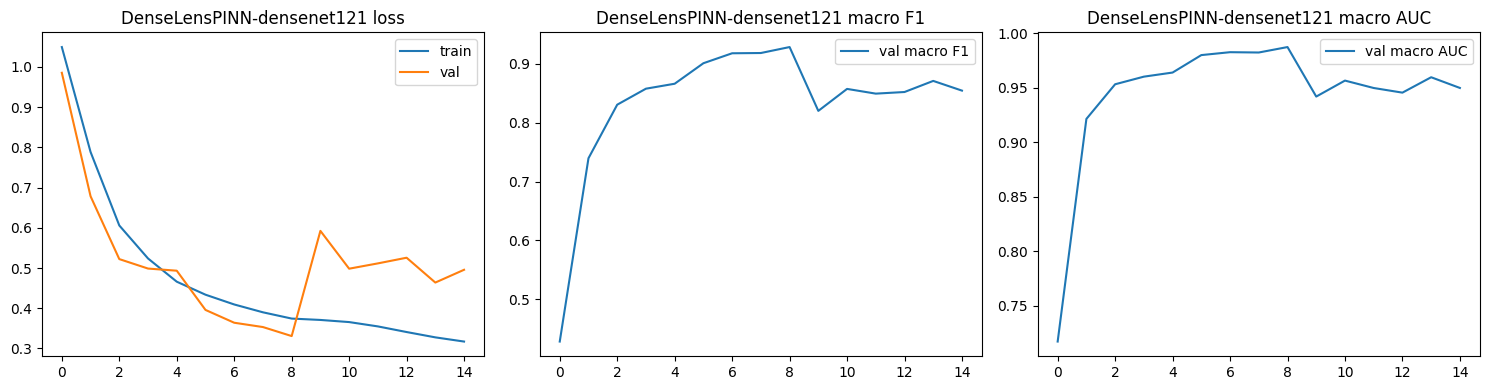

In [11]:

plot_history(history, model_name=f'DenseLensPINN-{cfg.backbone_name}')


In [12]:

def evaluate_model(model, loader, cfg: CFG, device):
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
    model.eval()
    y_true, y_prob, losses = [], [], []
    theta_all = []

    with torch.no_grad():
        from tqdm.auto import tqdm
        for image, pre, target in tqdm(loader, desc='final eval'):
            image = image.to(device)
            pre = pre.to(device)
            target = target.to(device)
            theta_e, _, logits = maybe_tta_predict(model, image, pre)
            probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
            loss = criterion(logits, target)
            y_true.extend(target.detach().cpu().numpy())
            y_prob.extend(probs)
            theta_all.extend(theta_e.detach().cpu().numpy().reshape(-1).tolist())
            losses.append(loss.item())

    metrics, per_class_auc, y_pred = compute_multiclass_metrics(y_true, y_prob, cfg.class_names)
    metrics['loss'] = float(np.mean(losses))
    return metrics, per_class_auc, np.asarray(y_true), np.asarray(y_pred), np.asarray(y_prob), np.asarray(theta_all)

metrics, per_class_auc, y_true, y_pred, y_prob, theta_all = evaluate_model(model, val_loader, cfg, device)
print('Validation metrics:')
for k, v in metrics.items():
    print(f'{k}: {v}')
print('Per-class AUC:', per_class_auc)
print(classification_report(y_true, y_pred, target_names=list(cfg.class_names)))
print('Predicted Einstein radius summary:')
print(pd.Series(theta_all).describe())


final eval:   0%|          | 0/938 [00:00<?, ?it/s]

Validation metrics:
accuracy: 0.9286666666666666
micro_f1: 0.9286666666666666
macro_f1: 0.928325029520547
macro_auc: 0.9872466133333333
micro_auc: 0.9882801955555557
loss: 0.33077555604136066
Per-class AUC: {'no': 0.98857736, 'sphere': 0.9817924800000001, 'vort': 0.9913700000000001}
              precision    recall  f1-score   support

          no       0.87      1.00      0.93      2500
      sphere       0.99      0.85      0.91      2500
        vort       0.95      0.94      0.95      2500

    accuracy                           0.93      7500
   macro avg       0.93      0.93      0.93      7500
weighted avg       0.93      0.93      0.93      7500

Predicted Einstein radius summary:
count    7500.000000
mean        0.052485
std         0.000004
min         0.052475
25%         0.052482
50%         0.052485
75%         0.052487
max         0.052503
dtype: float64


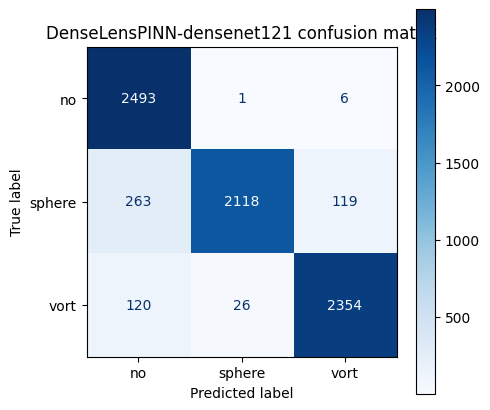

In [13]:

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(cfg.class_names)).plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'DenseLensPINN-{cfg.backbone_name} confusion matrix')
plt.show()



## Suggested next runs

I would run these in this order:

1. **Baseline corrected run**
   - `densenet121`, `patch_size=25`, `embed_dim=256`, `vit_depth=2`
2. **Backbone-only change**
   - same settings, but `backbone_name='densenet169'`
3. **Slightly lighter ViT**
   - `embed_dim=192`, `num_heads=6`, `vit_depth=2`
4. **If overfitting appears**
   - keep `densenet121`, raise `dropout` to `0.25`, keep all else fixed
5. **If underfitting appears**
   - keep `densenet121`, raise `epochs` to `30`, patience to `8`

I would **not** start by changing everything at once.



## Why this should behave better than your current notebook

The main reason is not just “better hyperparameters”. The main reason is **gradient flow**.

Your current notebook reconstructs the source with integer indexing and scatter-add. That makes the physics path effectively non-differentiable with respect to the predicted lens parameter. Once that happens, the ViT / PINN branch cannot meaningfully learn the lens inversion; it mostly becomes decoration.

Here, the physics path uses a **continuous differentiable warp** (`grid_sample`), so the classifier loss can push gradients back through:

- the DenseNet feature difference,
- the reconstructed source,
- the predicted Einstein radius,
- the ViT tokenizer and transformer blocks.

That is the single most important architectural correction.
